In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NC_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #90
print(count_no) #131
print(count_mci) #218

151
211
475


In [3]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','ind':'3','ans':'4'}
for i in data_ad:   #第13行开始为基因、蛋白水平
    j= i[16:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)

In [4]:
normal_arrays=[]
for i in data_normal:
    j= i[16:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)

In [5]:
mci_arrays=[]
for i in data_mci:
    j= i[16:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [6]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # 推荐：引入激活函数库

# 1. 转换数据为 Tensor
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

# 2. 定义网络层 
# 关键修复：输入维度由 45 改为 52 (匹配你的数据列数)
# 关键优化：使用不同的变量名 (fc1, fc2, fc3) 防止层被覆盖
fc1 = nn.Linear(52, 32)
fc2 = nn.Linear(32, 16)
fc3 = nn.Linear(16, 1)

# 3. 前向传播
# 注意：多层网络通常需要在层与层之间加激活函数(如 ReLU)，否则它数学上等价于单层网络。
# 为了保持代码运行，这里先按你的逻辑写，如果需要增加非线性能力，请取消注释 relu 行。

# 第一层
ad_tensor = fc1(ad_tensor)
# ad_tensor = F.relu(ad_tensor) 
normal_tensor = fc1(normal_tensor)
# normal_tensor = F.relu(normal_tensor)
mci_tensor = fc1(mci_tensor)
# mci_tensor = F.relu(mci_tensor)

# 第二层
ad_tensor = fc2(ad_tensor)
# ad_tensor = F.relu(ad_tensor)
normal_tensor = fc2(normal_tensor)
# normal_tensor = F.relu(normal_tensor)
mci_tensor = fc2(mci_tensor)
# mci_tensor = F.relu(mci_tensor)

# 第三层 (输出层)
ad_tensor = fc3(ad_tensor)
normal_tensor = fc3(normal_tensor)
mci_tensor = fc3(mci_tensor)

# 4. 打印结果
print('AD_tensor shape:', ad_tensor.shape)      # 预期: (151, 1)
print('Normal_tensor shape:', normal_tensor.shape) # 预期: (211, 1)
print('MCI_tensor shape:', mci_tensor.shape)    # 预期: (475, 1)

AD_tensor shape: torch.Size([151, 1])
Normal_tensor shape: torch.Size([211, 1])
MCI_tensor shape: torch.Size([475, 1])


In [8]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        # 替换字典中的值
        row = [replace_dict.get(item, item) for item in row]
        # 将类别型变量转换为数值
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[2:16])
    return np.array(processed_data)

In [9]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [10]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [3,4,5,6,7]  # gender, education, hispanic, race
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(14, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([151, 1])
normal.EHR---> torch.Size([211, 1])
mci.EHR---> torch.Size([475, 1])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
#医学图像
nii = CNN_3D(num_class=1)
nii= nii.to(device)
all_ad = 'ad_nii_KG/'
all_normal = 'normal_nii_kg/'
all_mci = 'NC_nii_kg/'
dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

In [13]:

nii_folders = {
    'ad': 'ad_nii_KG',
    'normal': 'normal_nii_kg',  
    'mci': 'NC_nii_kg'       
}

ad_df = pd.read_csv('AD.csv')
normal_df = pd.read_csv('normal.csv')
mci_df = pd.read_csv('mci.csv')

# 提取所有实体
entities = set()
for df in [ad_df, normal_df, mci_df]:
    for col in df.columns[8:]:
        entities.update(df[col].astype(str).unique())


entities.update(df['filename'].astype(str).unique())

entity2id = {}
with open('entity2id.txt', 'r') as f:
    for line in f:
        entity, id = line.strip().split('\t')
        entity2id[entity] = id  


entity_embeddings = torch.randn(len(entity2id), 32)

# 定义TransE模型类
class TransEextract:
    def __init__(self, entity_embeddings, entity2id):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = {id: idx for idx, id in enumerate(sorted(entity2id.values()))}

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            entity_id = self.entity2id[entity]
            entity_index = self.id_to_index[entity_id]
            return self.entity_embeddings[entity_index]
        else:
            raise ValueError(f"Entity {entity} not found in entity2id mapping")

# 初始化模型
model = TransEextract(entity_embeddings, entity2id)

# 获取嵌入向量
def get_embeddings(df, model, nii_folder):
    embeddings_list = []
    # 建议加上计数，方便调试
    valid_file_count = 0 
    
    for index, row in df.iterrows():
        # 1. 检查 .nii 文件是否存在 (保持与其他模态一致的筛选逻辑)
        nii_file = row.iloc[1] 
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            continue 
        
        valid_file_count += 1
        
        row_embeddings = []
        # 收集实体嵌入
        for col in df.columns[8:]:  
            entity = str(row[col])
            if entity != '0' and entity !='' and entity in model.entity2id:
                row_embeddings.append(model.get_entity_embedding(entity))

        filename = str(row['filename'])
        if filename in model.entity2id:
            row_embeddings.append(model.get_entity_embedding(filename))
        
        # 2. 修正逻辑：即使没有找到实体，也要占位！
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
        else:
            # 如果没有找到任何实体，使用全0向量填充 (32是你的embedding维度)
            # 这样可以保证人数与其他模态（如影像特征）对齐
            mean_embedding = torch.zeros(32) 
            
        embeddings_list.append(mean_embedding)

    
    if not embeddings_list:
        return torch.empty((0, 32))
    
    print(f"Processed {valid_file_count} valid files.")
    return torch.stack(embeddings_list)
    
ad_transe = get_embeddings(ad_df, model, nii_folders['ad'])
mci_transe = get_embeddings(mci_df, model, nii_folders['mci'])
normal_transe = get_embeddings(normal_df, model, nii_folders['normal'])

print(f"ad_transe shape: {ad_transe.shape}")
print(f"mci_transe shape: {mci_transe.shape}")
print(f"normal_transe shape: {normal_transe.shape}")

Processed 151 valid files.
Processed 475 valid files.
Processed 211 valid files.
ad_transe shape: torch.Size([151, 32])
mci_transe shape: torch.Size([475, 32])
normal_transe shape: torch.Size([211, 32])


In [14]:
'''# 随机生成 transe_embeddings
batch_size_ad = len(ad_EHR)
batch_size_mci = len(mci_EHR)
batch_size_normal = len(normal_EHR)
transe_embed_dim = 32
ad_transe = torch.randn(batch_size_ad, transe_embed_dim)
mci_transe = torch.randn(batch_size_mci, transe_embed_dim)
normal_transe = torch.randn(batch_size_normal, transe_embed_dim)'''

'# 随机生成 transe_embeddings\nbatch_size_ad = len(ad_EHR)\nbatch_size_mci = len(mci_EHR)\nbatch_size_normal = len(normal_EHR)\ntranse_embed_dim = 32\nad_transe = torch.randn(batch_size_ad, transe_embed_dim)\nmci_transe = torch.randn(batch_size_mci, transe_embed_dim)\nnormal_transe = torch.randn(batch_size_normal, transe_embed_dim)'

In [15]:
transe_embed_dim = 32
X_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor, ad_transe], dim=1)  # [batch_size_ad, EHR_dim + output_dim + tensor_dim + transe_embed_dim]
X_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  

X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [16]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [17]:
embed_dim = 32
transe_embed_dim = 32
num_epochs = 300
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-4

transe_model = TransEModel(num_entities=764, num_relations=4, embed_dim=200)
transe_model.load_state_dict(torch.load('transe.ckpt', map_location=torch.device('cpu')))
transe_model.eval()

model = KGMultiModalTransformer(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

Epoch 1/300, Train Loss: 1.1115, Train AUC: 0.4773  test Loss: 1.0904, test AUC: 0.4834
Epoch 2/300, Train Loss: 1.0888, Train AUC: 0.5318  test Loss: 1.0914, test AUC: 0.4502
Epoch 3/300, Train Loss: 1.0824, Train AUC: 0.5407  test Loss: 1.1038, test AUC: 0.4757
Epoch 4/300, Train Loss: 1.0833, Train AUC: 0.5306  test Loss: 1.1083, test AUC: 0.4747
Epoch 5/300, Train Loss: 1.0777, Train AUC: 0.5502  test Loss: 1.1129, test AUC: 0.4704
Epoch 6/300, Train Loss: 1.0935, Train AUC: 0.5255  test Loss: 1.1166, test AUC: 0.4765
Epoch 7/300, Train Loss: 1.0821, Train AUC: 0.5316  test Loss: 1.1125, test AUC: 0.4910
Epoch 8/300, Train Loss: 1.0732, Train AUC: 0.5571  test Loss: 1.1135, test AUC: 0.4891
Epoch 9/300, Train Loss: 1.0886, Train AUC: 0.5232  test Loss: 1.1115, test AUC: 0.5049
Epoch 10/300, Train Loss: 1.0748, Train AUC: 0.5449  test Loss: 1.1109, test AUC: 0.4963
Epoch 11/300, Train Loss: 1.0847, Train AUC: 0.5510  test Loss: 1.1049, test AUC: 0.5076
Epoch 12/300, Train Loss: 1.08

In [18]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.6194
Precision: 0.5848
Recall:    0.5227
F1 Score:  0.5420
AUC-ROC:   0.7456


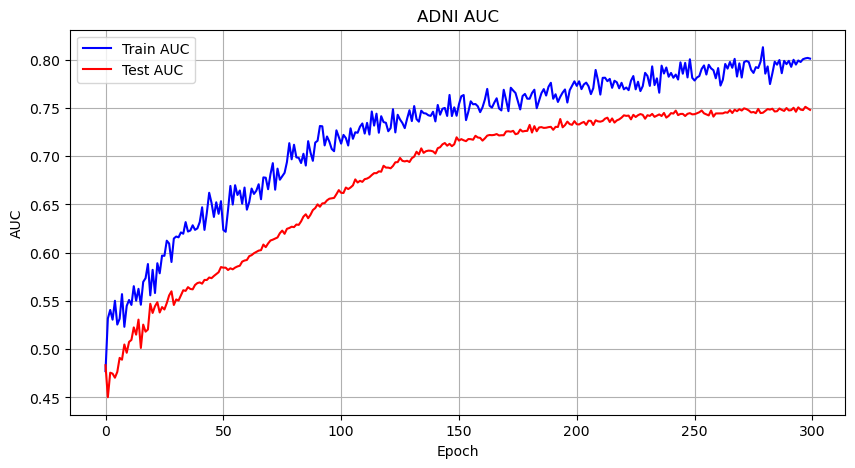

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("ADNI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

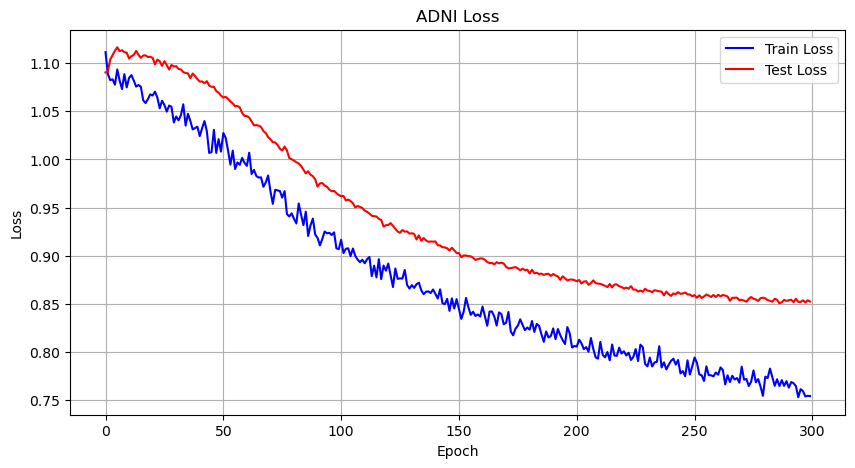

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("ADNI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()